# 🧠 Deep Learning & Convolutional Neural Networks
## From Theory to Practice with PyTorch & TorchVision

Welcome! This notebook is the continuation of our Machine Learning session.

---

## 📚 Learning Outcomes

By the end of this notebook, you will be able to:
- Understand **why** deep learning outperforms classical ML on images
- Build a **neural network from scratch** using only NumPy
- Understand **Convolutional Neural Networks (CNNs)** and how they see images
- Train a CNN with **PyTorch** to classify images
- Use **TorchVision pretrained models** (transfer learning)
- Complete a real **image classification project**

---

> 💡 **Remember:** Deep Learning = Machine Learning with many layers. Think of it as stacking simple operations on top of each other!

## get the answer of the exercices and quizzes
## get an object detection example & live webcam gender detection example


### claude prompt
Thank's, now for the machine learni ng notebook, the first one i want you to give more code cells with more exampels and 


```python

# Linear regresion from scratch with the houses example with few lines and with printing the loss and the weights at each step

# draw graphs with the models predictions and the real data to show how the model is learning and improving over time



# logistic regression with some real data not randomly generated data, and show the decision boundary and how it changes with the training process

```



for deep learning i want you to : 

* give more examples, for spam detection, house price prediction, multi categroy detection (10 animals labels detection for example)

* for the cnn models from scratch give training examples as well



give an object detection example ass well for deep learning.



and give me an example model which predicts the gender using the webcam in realtime thanks.



and last, give me the answers of your exercices and quizz in both notebooks

## 🔧 Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install torch torchvision matplotlib numpy scikit-learn

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 MB 1.7 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 2.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.6 MB/s eta 0:00:0000:0100:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (12 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

# PyTorch — the main deep learning library
import torch
import torch.nn as nn                    # Neural network layers
import torch.optim as optim              # Optimizers (like SGD, Adam)
import torch.nn.functional as F         # Activation functions, etc.
from torch.utils.data import DataLoader, TensorDataset, Dataset  # Batch data loading

# TorchVision — computer vision tools for PyTorch
import torchvision
import torchvision.transforms as transforms   # Image transformations
import torchvision.datasets as tv_datasets    # Built-in datasets
import torchvision.models as models           # Pretrained models

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

# Check if GPU is available (much faster training!)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # windows
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # mac 
print(f'✅ Libraries imported!')
print(f'📦 PyTorch version: {torch.__version__}')
print(f'💻 Using device: {device}  {"(GPU! 🚀)" if str(device)=="mps" else "(CPU — training will be slower)"}')

✅ Libraries imported!
📦 PyTorch version: 2.10.0
💻 Using device: mps  (GPU! 🚀)


In [4]:
device

device(type='mps')

---
# PART 1 — Theory of Deep Learning

## 🧠 From Logistic Regression to Neural Networks

Recall Logistic Regression: `output = σ(w·x + b)`

A **Neural Network** just stacks many of these in layers!

```
Input → [Layer 1] → [Layer 2] → ... → [Output Layer] → Prediction
```

Each layer learns to detect **increasingly complex patterns**:

```
Layer 1: Detects edges (lines, corners)
Layer 2: Combines edges into shapes (circles, rectangles)
Layer 3: Combines shapes into objects (eyes, wheels)
Layer 4: Combines objects into categories (face, car)
```

## Key Concepts

| Term | Meaning |
|------|---------|
| **Neuron** | One unit that computes: `output = activation(w·x + b)` |
| **Layer** | A group of neurons that process data together |
| **Activation function** | Non-linear function applied after each layer (ReLU, sigmoid, tanh) |
| **Forward pass** | Input flows through the network to produce a prediction |
| **Backpropagation** | Gradient of error flows backwards to update all weights |
| **Epoch** | One complete pass through the training dataset |
| **Batch** | A small group of samples processed together |

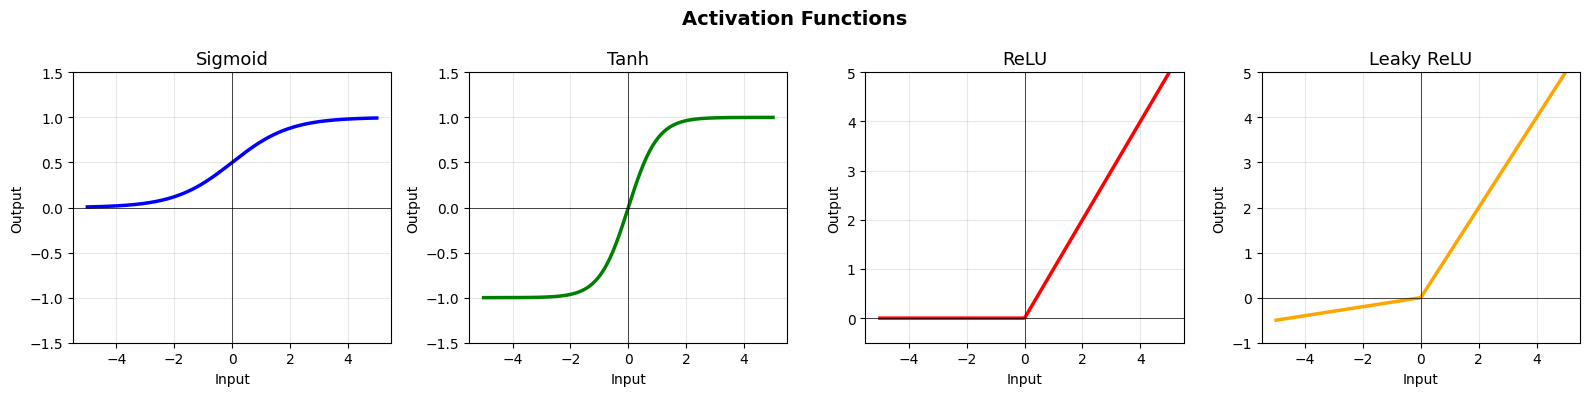

💡 ReLU is the most popular choice for hidden layers today!
   It is fast and avoids the "vanishing gradient" problem.


In [6]:
# -------------------------------------------------------
# Visualize activation functions
# These are what give neural networks their power!
# Without them, stacking layers would be useless.
# -------------------------------------------------------

x = np.linspace(-5, 5, 200)

# Define the activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh    = np.tanh(x)
relu    = np.maximum(0, x)          # ReLU: max(0, x)
leaky   = np.where(x > 0, x, 0.1 * x)  # Leaky ReLU

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, func, name, color in zip(
    axes,
    [sigmoid, tanh, relu, leaky],
    ['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU'],
    ['blue', 'green', 'red', 'orange']
):
    ax.plot(x, func, color=color, linewidth=2.5)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Input')
    ax.set_ylabel('Output')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.5, 1.5)

axes[2].set_ylim(-0.5, 5)  # ReLU goes up
axes[3].set_ylim(-1.0, 5)

plt.suptitle('Activation Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 ReLU is the most popular choice for hidden layers today!')
print('   It is fast and avoids the "vanishing gradient" problem.')

---
# PART 2 — Neural Network From Scratch (NumPy)

Before using PyTorch, let's build a tiny neural network manually.
This will make you understand what the library does under the hood!

**Architecture:** Input(64) → Hidden(64) → Hidden(32) → Output(10)

For 64-pixel digit images → predicting one of 10 digits

In [ ]:
# -------------------------------------------------------
# NEURAL NETWORK FROM SCRATCH with NumPy
# A 2-hidden-layer network for classification
# -------------------------------------------------------

✅ Neural network class defined!


In [ ]:
# -------------------------------------------------------
# Train our scratch neural network on digit classification
# -------------------------------------------------------
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load digits dataset
digits = datasets.load_digits()
X_d = digits.images.reshape(len(digits.images), -1).astype(float) / 16.0  # normalize to [0,1]
y_d = digits.target

X_tr, X_te, y_tr, y_te = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

# Create and train network
# Input: 64 features | Hidden: 128, 64 | Output: 10 classes

---
# Example 1: Spam Detection (Neural Network)

**Task:** Classify emails as spam (1) or not spam (0)

**Features:** Bag-of-words — frequency of 10 spam-related keywords

This is a classic NLP-style classification that also applies to:
- Malware detection
- Fraud detection
- Medical triage

In [ ]:
# Class Work

---
# PART 3 — Example 2: House Price Prediction (Regression NN)

**Task:** Predict house price from multiple features

**Dataset:** California housing (sklearn) — real census data
- Features: median income, house age, rooms, bedrooms, population, households, lat, lon
- Target: median house value (in $100k)

This shows how neural networks handle **regression** (not just classification).

In [ ]:
# Class Work

---
# PART 3 — Theory of Convolutional Neural Networks

## 🔍 Why CNNs for Images?

In a regular (fully-connected) neural network:
- A 224×224 RGB image = **150,528 inputs**
- First hidden layer with 1000 neurons = **150 MILLION weights** 😱
- This is too slow and prone to overfitting!

**CNNs solve this with 3 key ideas:**

### 1. 🔲 Convolution (local connections)
Instead of connecting every pixel to every neuron, we use a small **filter (kernel)** that slides over the image.
- A 3×3 filter has only **9 weights** — shared across the whole image!
- The filter learns to detect a specific pattern (edge, color gradient, etc.)

### 2. 📉 Pooling (spatial reduction)
After convolution, we **downsample** the feature maps.
- **Max pooling:** Take the maximum value in each 2×2 region
- This makes the network robust to small shifts in position

### 3. 📚 Multiple layers
```
Conv Layer 1 → learns edges
Conv Layer 2 → learns textures
Conv Layer 3 → learns object parts
...
Dense Layer  → classifies
```

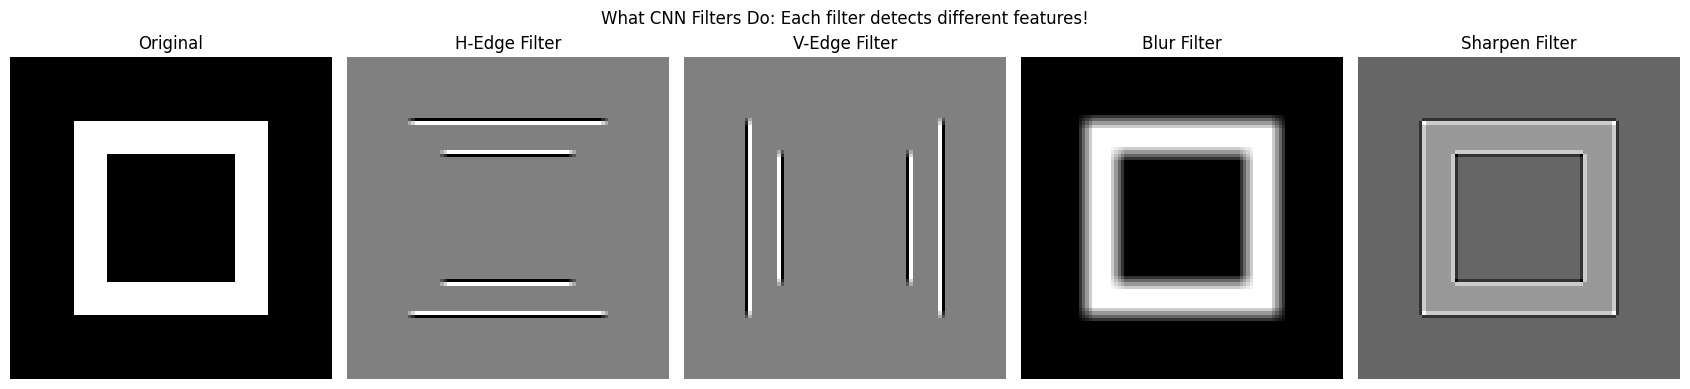

💡 In CNNs, the computer learns these filter weights automatically!
   We do not need to design them by hand.


In [9]:
# -------------------------------------------------------
# Visualize what convolution does to an image
# Let's apply different filters manually using OpenCV
# -------------------------------------------------------

# Create a simple test image (gradient + shape)
img = np.zeros((100, 100), dtype=np.float32)
img[20:80, 20:80] = 200   # white square
img[30:70, 30:70] = 0     # black square inside

# Define filters (kernels)
kernel_edge_h = np.array([[-1, -1, -1],   # Horizontal edge detector
                           [ 2,  2,  2],
                           [-1, -1, -1]], dtype=np.float32)

kernel_edge_v = np.array([[-1,  2, -1],   # Vertical edge detector
                           [-1,  2, -1],
                           [-1,  2, -1]], dtype=np.float32)

kernel_blur   = np.ones((5, 5), dtype=np.float32) / 25  # Blur/average filter

kernel_sharp  = np.array([[ 0, -1,  0],   # Sharpening filter
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)

# Apply convolutions using OpenCV
out_edge_h = cv2.filter2D(img, -1, kernel_edge_h)
out_edge_v = cv2.filter2D(img, -1, kernel_edge_v)
out_blur   = cv2.filter2D(img, -1, kernel_blur)
out_sharp  = cv2.filter2D(img, -1, kernel_sharp)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(17, 4))
titles = ['Original', 'H-Edge Filter', 'V-Edge Filter', 'Blur Filter', 'Sharpen Filter']
images = [img, out_edge_h, out_edge_v, out_blur, out_sharp]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('What CNN Filters Do: Each filter detects different features!', fontsize=12)
plt.tight_layout()
plt.show()

print('💡 In CNNs, the computer learns these filter weights automatically!')
print('   We do not need to design them by hand.')

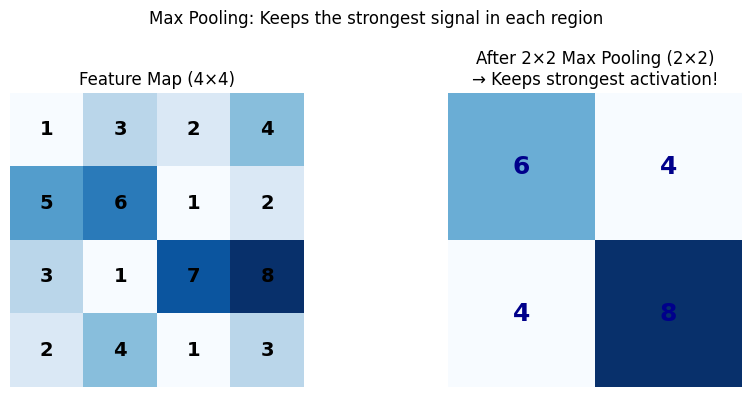

In [10]:
# -------------------------------------------------------
# Visualize Max Pooling
# -------------------------------------------------------

# Example feature map (after convolution)
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [3, 1, 7, 8],
    [2, 4, 1, 3]
], dtype=float)

# 2x2 max pooling with stride 2
pooled = np.zeros((2, 2))
pooled[0, 0] = feature_map[0:2, 0:2].max()   # top-left 2x2 → max = 6
pooled[0, 1] = feature_map[0:2, 2:4].max()   # top-right 2x2 → max = 4
pooled[1, 0] = feature_map[2:4, 0:2].max()   # bottom-left 2x2 → max = 4
pooled[1, 1] = feature_map[2:4, 2:4].max()   # bottom-right 2x2 → max = 8

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(feature_map, cmap='Blues')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(int(feature_map[i,j])), ha='center', va='center', fontsize=14, fontweight='bold')
axes[0].set_title('Feature Map (4×4)')
axes[0].axis('off')

axes[1].imshow(pooled, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(int(pooled[i,j])), ha='center', va='center', fontsize=18, fontweight='bold', color='darkblue')
axes[1].set_title('After 2×2 Max Pooling (2×2)\n→ Keeps strongest activation!')
axes[1].axis('off')

plt.suptitle('Max Pooling: Keeps the strongest signal in each region', fontsize=12)
plt.tight_layout()
plt.show()

---
# PART 4 — CNN from Scratch (NumPy)

Let's implement a simplified 1-layer convolution manually to understand what's happening inside PyTorch.

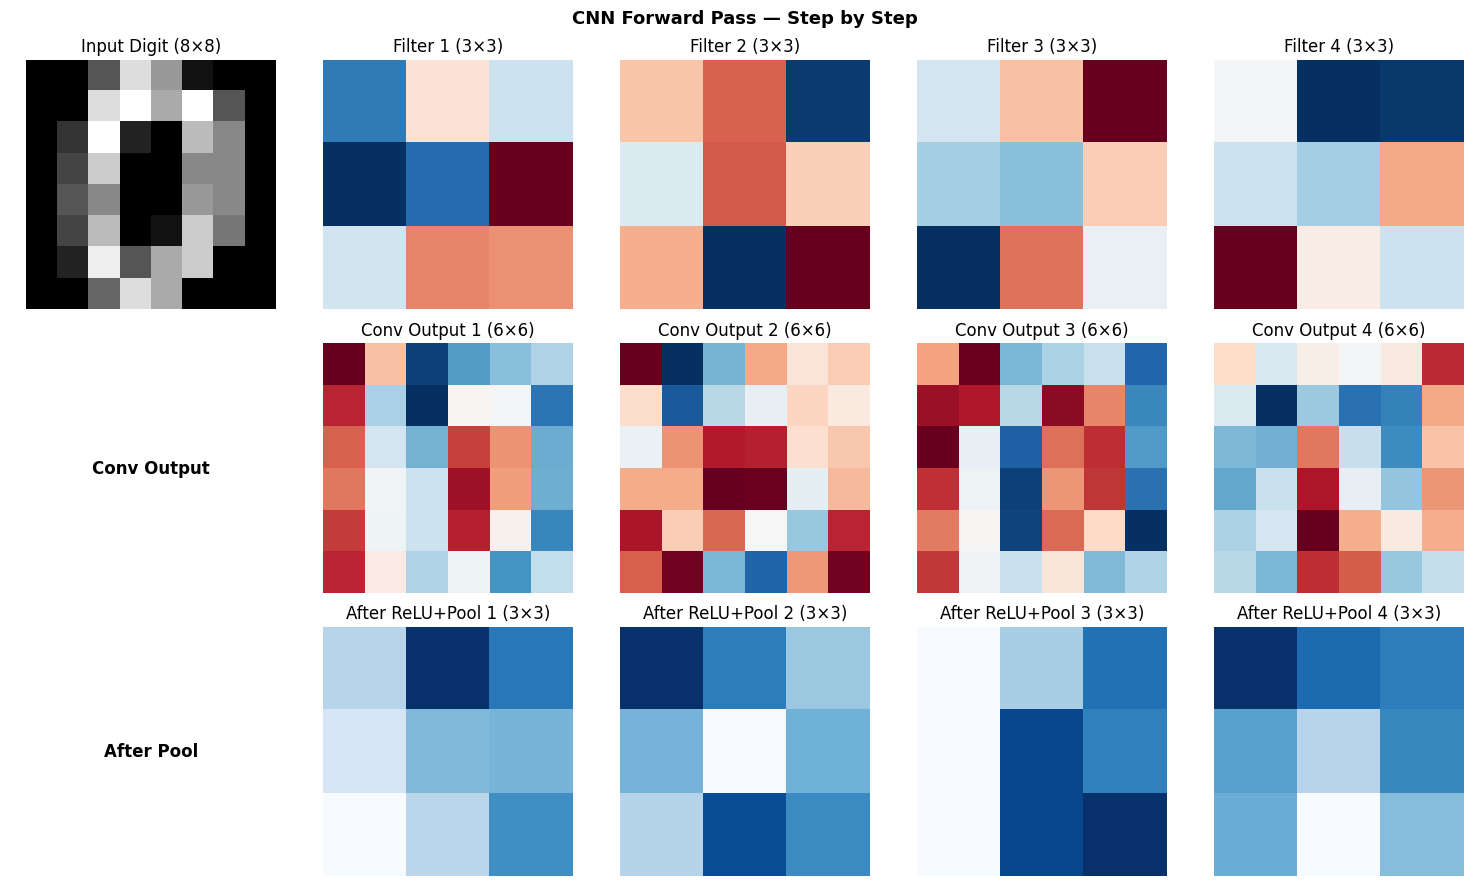

In [18]:
# -------------------------------------------------------
# CONVOLUTION FROM SCRATCH
# One 2D convolution step, no padding, stride 1
# -------------------------------------------------------

def conv2d_scratch(image, kernel):
    """
    Apply a 2D convolution to an image using a given kernel.
    This is what ONE filter in a CNN layer does.
    """
    img_h, img_w   = image.shape
    ker_h, ker_w   = kernel.shape
    
    # Output size is smaller due to no padding
    out_h = img_h - ker_h + 1
    out_w = img_w - ker_w + 1
    output = np.zeros((out_h, out_w))
    
    # Slide the kernel over the image
    for i in range(out_h):
        for j in range(out_w):
            # Extract the patch of image that the kernel covers
            patch = image[i:i+ker_h, j:j+ker_w]
            
            # Element-wise multiply and sum → this is the convolution!
            output[i, j] = np.sum(patch * kernel)
    
    return output


def max_pool2d_scratch(feature_map, pool_size=2):
    """
    Apply 2D max pooling with the given pool size.
    Reduces spatial dimensions by 2x.
    """
    h, w = feature_map.shape
    out_h = h // pool_size
    out_w = w // pool_size
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            region = feature_map[i*pool_size:(i+1)*pool_size,
                                  j*pool_size:(j+1)*pool_size]
            output[i, j] = region.max()
    
    return output


# --- Demo: Apply 4 random filters to a digit image ---
digit_img = digits.images[0]   # first digit image (8x8)

np.random.seed(0)
filters = [np.random.randn(3, 3) for _ in range(4)]  # 4 random 3x3 filters

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Row 1: Show filters
axes[0, 0].imshow(digit_img, cmap='gray')
axes[0, 0].set_title('Input Digit (8×8)')
axes[0, 0].axis('off')
for i, f in enumerate(filters):
    axes[0, i+1].imshow(f, cmap='RdBu')
    axes[0, i+1].set_title(f'Filter {i+1} (3×3)')
    axes[0, i+1].axis('off')

# Row 2: Convolution outputs
axes[1, 0].axis('off')
conv_outputs = []
for i, f in enumerate(filters):
    out = conv2d_scratch(digit_img, f)
    conv_outputs.append(out)
    axes[1, i+1].imshow(out, cmap='RdBu')
    axes[1, i+1].set_title(f'Conv Output {i+1} (6×6)')
    axes[1, i+1].axis('off')

# Row 3: After pooling
axes[2, 0].axis('off')
for i, co in enumerate(conv_outputs):
    relu_out = np.maximum(0, co)    # apply ReLU first
    pooled = max_pool2d_scratch(relu_out, pool_size=2)
    axes[2, i+1].imshow(pooled, cmap='Blues')
    axes[2, i+1].set_title(f'After ReLU+Pool {i+1} (3×3)')
    axes[2, i+1].axis('off')

# Row labels
for ax, label in zip([axes[0,0], axes[1,0], axes[2,0]], 
                     ['Filters', 'Conv Output', 'After Pool']):
    ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold',
            transform=ax.transAxes)

plt.suptitle('CNN Forward Pass — Step by Step', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PART 5 — 10-Animal Classification (CNN on CIFAR-10)

CIFAR-10 has 10 classes: ✈️ airplane, 🚗 automobile, 🐦 bird, 🐱 cat, 🦌 deer,
🐶 dog, 🐸 frog, 🐴 horse, 🚢 ship, 🚚 truck

We build a 3-block CNN in PyTorch and train it with data augmentation.

In [ ]:
# -------------------------------------------------------
# LOAD CIFAR-10 with TorchVision
# -------------------------------------------------------

# Define transforms

# Load dataset and apply transforms

# CIFAR-10 is a popular dataset of 60,000 32x32 color images in 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']
ANIMAL_IDX    = [2,3,4,5,6,7]   # bird, cat, deer, dog, frog, horse

In [26]:
# -------------------------------------------------------
# DEFINE OUR CNN IN PYTORCH
# Architecture:
#   Input: (3, 32, 32) — RGB image
#   Conv1: 32 filters → (32, 32, 32)
#   Pool1: 2x2 MaxPool → (32, 16, 16)
#   Conv2: 64 filters → (64, 16, 16)
#   Pool2: 2x2 MaxPool → (64, 8, 8)
#   Conv3: 128 filters → (128, 8, 8)
#   Pool3: 2x2 MaxPool → (128, 4, 4)
#   Flatten → 2048
#   FC1: 256 neurons
#   FC2: 10 classes
# -------------------------------------------------------

In [24]:
# -------------------------------------------------------
# TRAINING LOOP IN PYTORCH
# -------------------------------------------------------

In [25]:
# -------------------------------------------------------
# Plot training progress
# -------------------------------------------------------

---
# PART 6 — Transfer Learning with TorchVision Pretrained Models

## 🚀 What is Transfer Learning?

Training a deep CNN from scratch requires:
- Millions of images
- Days of GPU training

**Transfer Learning:** Start from a model already trained on millions of images (like ImageNet), and just fine-tune the last layers for our task!

```
Pretrained Model:
  [Feature Extractor] → learned from 1.2M ImageNet images
  [Classifier]        → for 1000 ImageNet classes

After Transfer Learning:
  [Feature Extractor] → FROZEN (keep these weights)
  [Classifier]        → REPLACED with our new classifier → TRAIN THIS
```

This works because early layers detect universal features (edges, textures) useful for any image task!

In [30]:
# -------------------------------------------------------
# TRANSFER LEARNING with ResNet-18
# ResNet-18 was trained on ImageNet (1.2M images, 1000 classes)
# -------------------------------------------------------

In [31]:
# -------------------------------------------------------
# Visualize predictions from the transfer learning model
# -------------------------------------------------------

---
# PART 7 — Object Detection with OpenCV DNN (YOLOv5-style)

**Object Detection** = locate objects AND classify them simultaneously

We use **OpenCV's DNN module** with a pretrained MobileNet-SSD model
(trained on COCO — 80 common objects).

```
Input image → CNN Backbone → Detection Head → Bounding Boxes + Class Labels + Confidence
```

> 💡 For production use, YOLOv8 (ultralytics library) is the current standard.

In [ ]:
# Class Work

---
# PART 8 — Visualizing What the CNN Learned

Let's look **inside** the CNN to understand what it learned to detect.

First conv layer filter shape: (32, 3, 3, 3)
  → 32 filters, 3 input channels, 3×3 spatial size


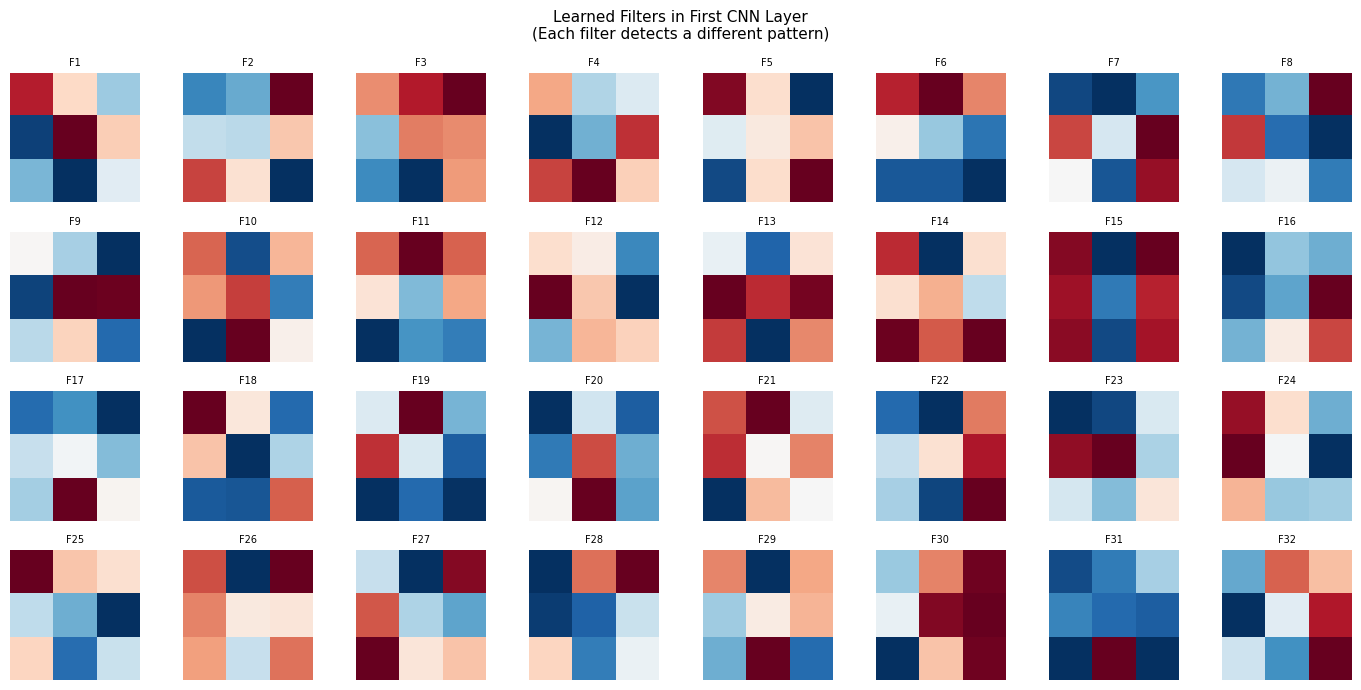

In [32]:
# -------------------------------------------------------
# Visualize learned filters from our trained CNN
# -------------------------------------------------------

# Get the weights from the first conv layer of our SimpleCNN
# Shape: (32, 3, 3, 3) → 32 filters, 3 channels, 3x3
first_layer_weights = cnn.conv1.weight.data.cpu().numpy()

print(f'First conv layer filter shape: {first_layer_weights.shape}')
print(f'  → 32 filters, 3 input channels, 3×3 spatial size')

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i in range(32):
    ax = axes[i // 8, i % 8]
    # Take mean across channels for visualization
    filt = first_layer_weights[i].mean(axis=0)
    filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)  # normalize to [0,1]
    ax.imshow(filt, cmap='RdBu')
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.suptitle('Learned Filters in First CNN Layer\n(Each filter detects a different pattern)', fontsize=11)
plt.tight_layout()
plt.show()

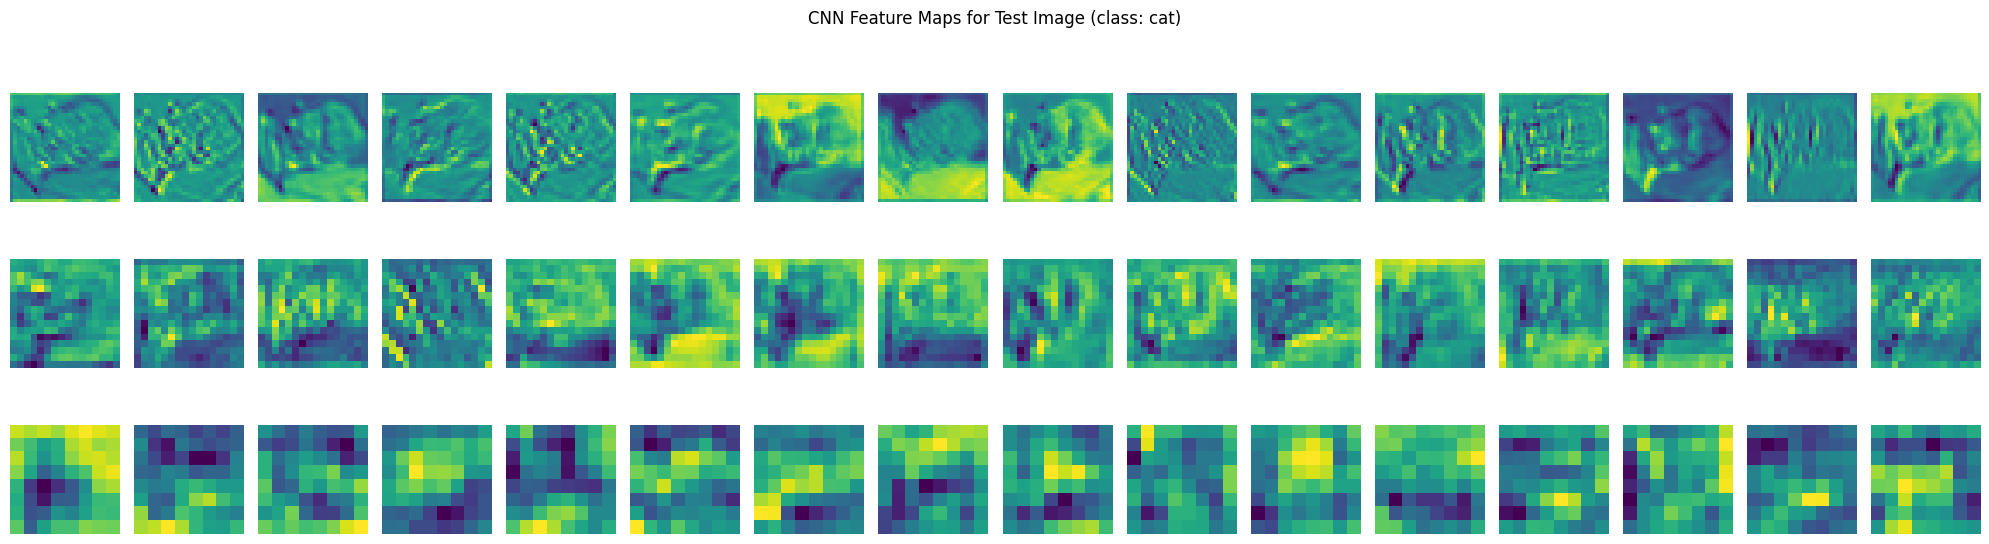

In [33]:
# -------------------------------------------------------
# Visualize feature maps (activations) for a test image
# -------------------------------------------------------

# Get one test image
test_img_tensor = test_images[0].unsqueeze(0).to(device)  # add batch dimension

# Hook to capture intermediate activations
activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

# Register hooks
cnn.conv1.register_forward_hook(hook_fn('conv1'))
cnn.conv2.register_forward_hook(hook_fn('conv2'))
cnn.conv3.register_forward_hook(hook_fn('conv3'))

# Run forward pass
cnn.eval()
with torch.no_grad():
    output = cnn(test_img_tensor)

# Plot
fig, axes = plt.subplots(3, 16, figsize=(20, 6))

for row, (layer_name, n_show) in enumerate([
    ('conv1', 16),  # show 16 of 32 filters
    ('conv2', 16),  # show 16 of 64 filters
    ('conv3', 16),  # show 16 of 128 filters
]):
    act = activations[layer_name][0]   # remove batch dim
    for col in range(n_show):
        ax = axes[row, col]
        feat_map = act[col].numpy()
        ax.imshow(feat_map, cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(layer_name, rotation=0, labelpad=40, fontsize=9)

plt.suptitle(f'CNN Feature Maps for Test Image (class: {CLASSES[test_labels_np[0]]})', fontsize=12)
plt.tight_layout()
plt.show()

---
# PART 9 — Real-Time Gender Prediction from Webcam

We use a **pretrained deep learning model** from OpenCV's model zoo:
- Face detector: OpenCV DNN with a Caffe ResNet face detector
- Gender classifier: Pretrained binary classifier (Male/Female)

Both models were trained on large face datasets and work in real time.

> 📷 Run this cell with your webcam connected. Press `Q` to quit.

In [ ]:
# class work

---
# 🏋️ Exercises

### Exercise 1 — Architecture
Add a 4th conv block to `AnimalCNN`. Does accuracy improve? Does training take longer?

### Exercise 2 — Data Augmentation
Add `transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1)` to the training transforms. How does it affect accuracy?

### Exercise 3 — Fine-Tune ResNet
After training the head, **unfreeze all layers** and train with `lr=1e-5` for 5 more epochs.

### Exercise 4 — MobileNetV2
Replace ResNet-18 with MobileNetV2: `models.mobilenet_v2(pretrained=True)`. Compare speed and accuracy.

### Exercise 5 — OpenCV + CNN
Load an image with `cv2.imread`, preprocess it, and run it through our trained `AnimalCNN`.

---
# ✅ Exercise Answers

In [ ]:
# ✏️ Exercise 1 — Add a 4th conv block



In [ ]:
# ✏️ Exercise 2 — More data augmentation



In [ ]:
# ✏️ Exercise 3 — Unfreeze ResNet-18



In [34]:
# ✏️ Exercise 4 — Try MobileNetV2



In [ ]:
# ✏️ Exercise 5 — Apply to OpenCV image



---
# 📝 Quiz

1. What is the **vanishing gradient problem**, and which activation helps avoid it?
2. What does **BatchNorm** do? Why is it helpful?
3. Why do we call `optimizer.zero_grad()` before each backward pass?
4. What is **data augmentation** and why does it help with overfitting?
5. Difference between **feature extraction** and **fine-tuning** in transfer learning?
6. 99% train acc, 55% test acc — what problem? How to fix?

✏️ **Your answers here:**

1. 
2. 
3. 
4. 
5. 
6. 

---
# 🎉 Summary

Congratulations! You've completed the Deep Learning & CNN session!

| Concept | What we did |
|---------|-------------|
| **DL Theory** | Neural network layers, activation functions, forward/backward pass |
| **NN Scratch** | Built a 2-layer network using only NumPy |
| **Convolution** | Implemented conv2d and max pooling from scratch |
| **CNN Theory** | Why CNNs are better for images (local connections, weight sharing) |
| **PyTorch CNN** | Built and trained a 3-layer CNN on CIFAR-10 |
| **Transfer Learning** | Fine-tuned ResNet-18 with only 5 epochs |
| **Visualization** | Saw what filters and feature maps look like |

---

## 🔮 What's Next?

You now have the full foundation! Possible next topics:

- **Object Detection:** YOLO, Faster R-CNN — detect WHERE objects are
- **Semantic Segmentation:** Label every pixel in an image
- **GANs:** Generate realistic images from noise
- **Vision Transformers (ViT):** Attention-based models replacing CNNs
- **Real-time inference:** Deploy your model on a webcam feed!

> 🌟 Great work! You went from raw pixels all the way to state-of-the-art deep learning!